In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\parih\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv('D:\SQL\oasis2_mri\oasis_longitudinal.csv')

In [4]:
# looking at my data
df.shape

(373, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), object(5)
memory usage: 43.8+ KB


In [6]:
df.isnull().sum()

Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64

In [7]:
df['Group'].value_counts()

Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64

In [8]:
df[df['Subject ID'] == 'OAS2_0181']

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
356,OAS2_0181,OAS2_0181_MR1,Demented,1,0,F,R,74,12,NaN,26.0,0.5,1171,0.733,1.499
357,OAS2_0181,OAS2_0181_MR2,Demented,2,539,F,R,75,12,NaN,NaN,1.0,1169,0.742,1.501
358,OAS2_0181,OAS2_0181_MR3,Demented,3,1107,F,R,77,12,NaN,NaN,1.0,1159,0.733,1.515


In [9]:
df = df.dropna(subset=['MMSE'])

In [10]:
group = df.groupby('Group')
group[['Age', 'MR Delay']].describe()


Age                                                     \
             count       mean       std   min   25%   50%   75%   max   
Group                                                                   
Converted     37.0  79.756757  7.425203  65.0  74.0  81.0  86.0  92.0   
Demented     144.0  76.263889  6.987487  61.0  71.0  76.0  81.0  98.0   
Nondemented  190.0  77.057895  8.096104  60.0  71.0  77.0  82.0  97.0   

            MR Delay                                                            
               count        mean         std  min  25%    50%      75%     max  
Group                                                                           
Converted       37.0  771.810811  767.296366  0.0  0.0  706.0  1422.00  2639.0  
Demented       144.0  447.395833  514.440075  0.0  0.0  488.0   679.75  2508.0  
Nondemented    190.0  670.242105  672.807019  0.0  0.0  631.0  1129.75  2517.0

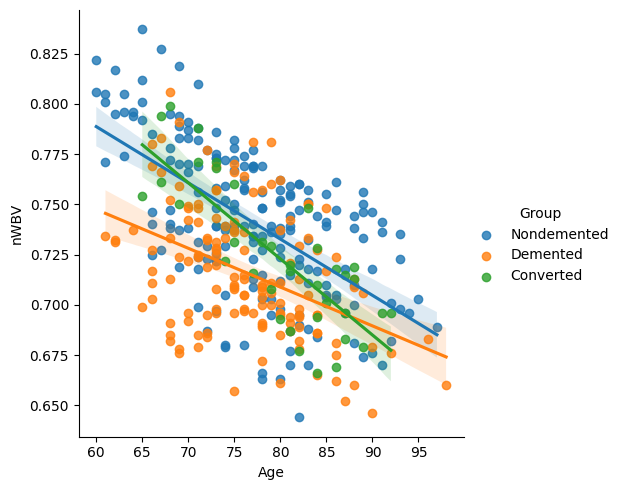

In [11]:
reg_plot = sns.lmplot(x="Age", y="nWBV", data=df, hue="Group")

<Axes: xlabel='MR Delay', ylabel='nWBV'>

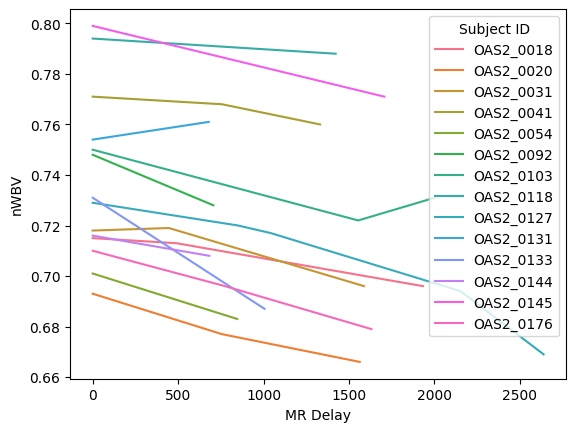

In [12]:
converted = df[df['Group'] == 'Converted'].copy()
sns.lineplot(x='MR Delay', y = 'nWBV', data = converted, hue = 'Subject ID')

In [13]:
converted['stage'] = np.where(converted['CDR'] < 0.5, 'early', 'later')

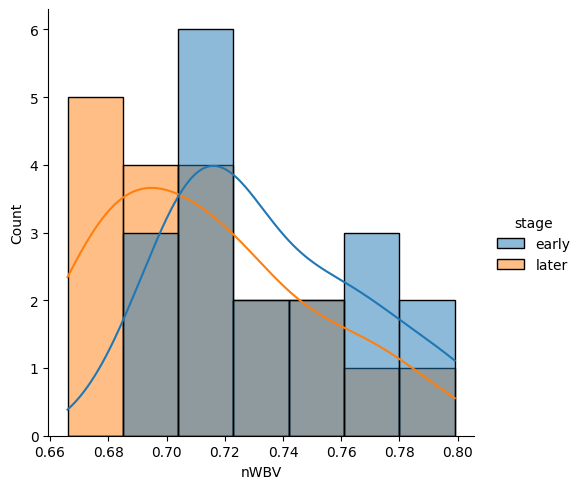

In [14]:
sns.displot(x='nWBV', data=converted, hue='stage', kde=True)

In [15]:
converted['stage'].value_counts()

stage
later    19
early    18
Name: count, dtype: int64

In [16]:
converted_subj_comparison = converted.groupby(['Subject ID' , 'stage'])['nWBV'].mean()
converted_subj_comparison = converted_subj_comparison.unstack()
converted_subj_comparison['difference'] = converted_subj_comparison['early'] - converted_subj_comparison['later']
converted_subj_comparison = converted_subj_comparison.sort_values('difference')
converted_subj_comparison = converted_subj_comparison.reset_index()

<Axes: xlabel='difference', ylabel='Subject ID'>

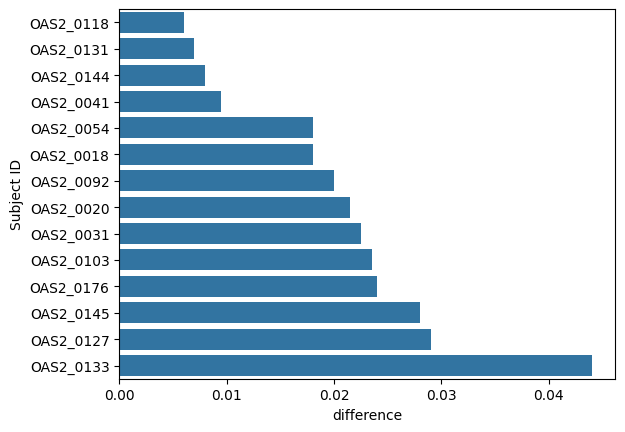

In [17]:
sns.barplot(y='Subject ID', x='difference',data=converted_subj_comparison)

<Axes: xlabel='nWBV', ylabel='stage'>

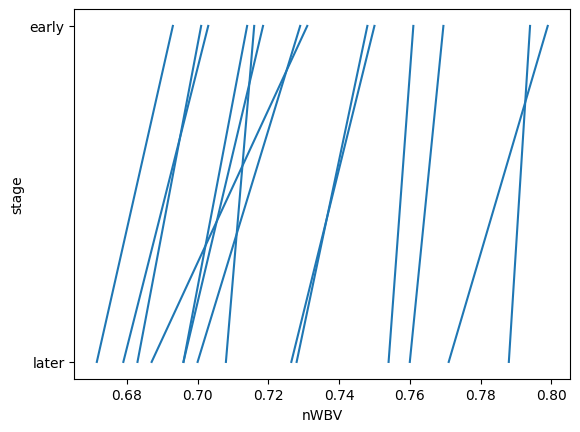

In [18]:
for_line = converted.groupby(['Subject ID' , 'stage'])['nWBV'].mean()
for_line = for_line.reset_index()
sns.lineplot(y='stage', x='nWBV', data=for_line, units='Subject ID', estimator=None)

<Axes: xlabel='CDR', ylabel='MMSE'>

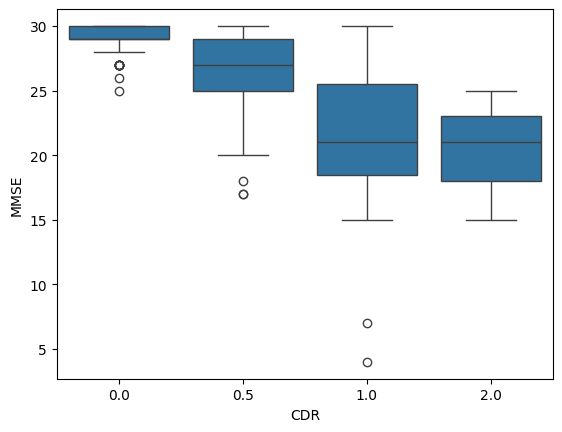

In [19]:
sns.boxplot(x='CDR', y='MMSE', data=df)

In [20]:
df.to_csv('oasis_cleaned.csv', index=False)